In [17]:
import numpy as np
import pandas as pd
import glob
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

%matplotlib inline


In [19]:
files = sorted(
    glob.glob("C*.csv"),
    key=lambda x: int(x.replace("C","").replace(".csv",""))
)

files


['C1.csv',
 'C2.csv',
 'C3.csv',
 'C4.csv',
 'C5.csv',
 'C6.csv',
 'C7.csv',
 'C8.csv',
 'C9.csv',
 'C10.csv']

In [20]:
dfs = []

for f in files:
    df = pd.read_csv(f)
    df['experiment'] = f.replace('.csv','')
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)


In [21]:
data.head()


,time (days),algae (10^6 cells/ml),rotifers (animals/ml),egg-ratio,eggs (per ml),dead animals (per ml),external medium (mu mol N / l),experiment
0,0.00,1.50,NaN,NaN,NaN,NaN,80.0,C1
1,0.95,0.83,5.42,0.00,0.00,0.4,80.0,C1
2,2.26,0.70,18.26,0.38,7.02,0.0,80.0,C1
3,2.91,0.38,17.86,0.19,3.41,0.4,80.0,C1
4,3.95,0.41,21.07,0.32,6.82,0.4,80.0,C1


In [22]:
data.columns = data.columns.str.strip()
data.columns


Index(['time (days)', 'algae (10^6 cells/ml)', 'rotifers (animals/ml)',
       'egg-ratio', 'eggs (per ml)', 'dead animals (per ml)',
       'external medium (mu mol N / l)', 'experiment'],
      dtype='object')

In [23]:
lv_data = data[
    [
        'time (days)',
        'algae (10^6 cells/ml)',
        'rotifers (animals/ml)',
        'experiment'
    ]
].dropna()

lv_data.head()


,time (days),algae (10^6 cells/ml),rotifers (animals/ml),experiment
1,0.95,0.83,5.42,C1
2,2.26,0.70,18.26,C1
3,2.91,0.38,17.86,C1
4,3.95,0.41,21.07,C1
5,4.95,0.39,17.46,C1


In [24]:
lv_data = lv_data.rename(columns={
    'time (days)': 'time',
    'algae (10^6 cells/ml)': 'prey',
    'rotifers (animals/ml)': 'predator'
})

lv_data.head()


,time,prey,predator,experiment
1,0.95,0.83,5.42,C1
2,2.26,0.70,18.26,C1
3,2.91,0.38,17.86,C1
4,3.95,0.41,21.07,C1
5,4.95,0.39,17.46,C1


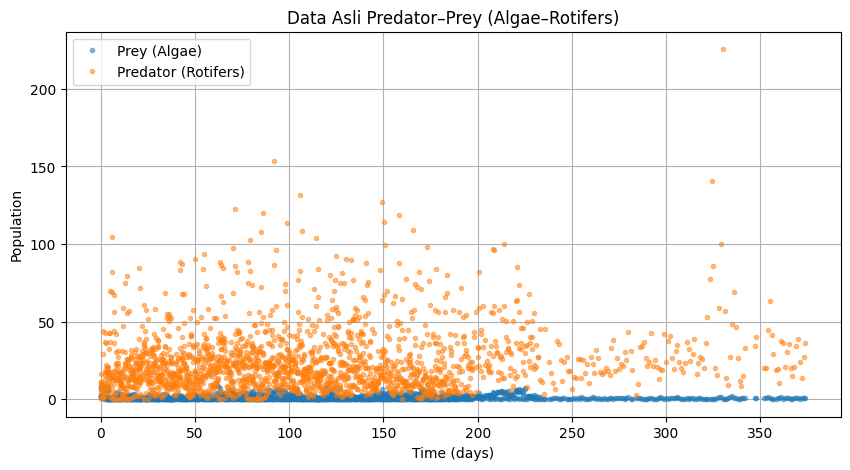

In [25]:
plt.figure(figsize=(10,5))
plt.plot(lv_data['time'], lv_data['prey'], '.', label='Prey (Algae)', alpha=0.5)
plt.plot(lv_data['time'], lv_data['predator'], '.', label='Predator (Rotifers)', alpha=0.5)

plt.xlabel("Time (days)")
plt.ylabel("Population")
plt.title("Data Asli Predator–Prey (Algae–Rotifers)")
plt.legend()
plt.grid(True)
plt.show()


In [26]:
def lotka_volterra(t, z, alpha, beta, delta, gamma):
    x, y = z
    dxdt = alpha*x - beta*x*y
    dydt = delta*x*y - gamma*y
    return [dxdt, dydt]


In [28]:
exp_id = 'C1'
exp_data = lv_data[lv_data['experiment'] == exp_id].copy()


In [29]:
exp_data = exp_data.sort_values('time')


In [30]:
t_data = exp_data['time'].values
x_data = exp_data['prey'].values
y_data = exp_data['predator'].values


In [31]:
def residuals(params):
    alpha, beta, delta, gamma = params
    sol = solve_ivp(
        lotka_volterra,
        (t_data.min(), t_data.max()),
        [x_data[0], y_data[0]],
        args=(alpha, beta, delta, gamma),
        t_eval=t_data
    )
    return np.concatenate([
        sol.y[0] - x_data,
        sol.y[1] - y_data
    ])

init_params = [1.0, 0.1, 0.1, 1.0]
result = least_squares(residuals, init_params, bounds=(0, np.inf))

alpha, beta, delta, gamma = result.x
alpha, beta, delta, gamma


(np.float64(1.0000000051958797),
 np.float64(0.10000000484039104),
 np.float64(0.09999999262060737),
 np.float64(1.0000000068359962))

In [32]:
sim = solve_ivp(
    lotka_volterra,
    (t_data.min(), t_data.max()),
    [x_data[0], y_data[0]],
    args=(alpha, beta, delta, gamma),
    t_eval=t_data
)

sim_x, sim_y = sim.y


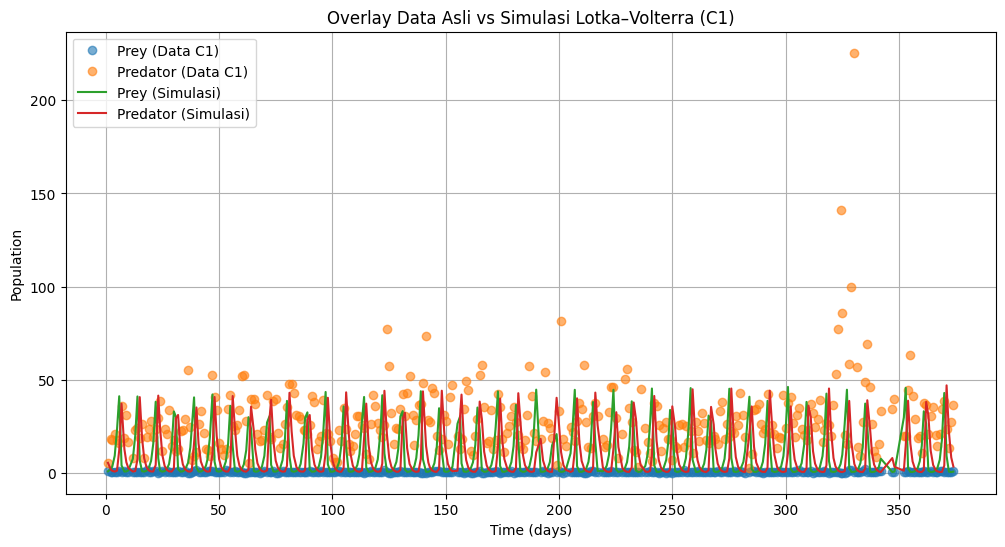

In [33]:
plt.figure(figsize=(12,6))

plt.plot(t_data, x_data, 'o', label='Prey (Data C1)', alpha=0.6)
plt.plot(t_data, y_data, 'o', label='Predator (Data C1)', alpha=0.6)

plt.plot(t_data, sim_x, '-', label='Prey (Simulasi)')
plt.plot(t_data, sim_y, '-', label='Predator (Simulasi)')

plt.xlabel("Time (days)")
plt.ylabel("Population")
plt.title("Overlay Data Asli vs Simulasi Lotka–Volterra (C1)")
plt.legend()
plt.grid(True)
plt.show()


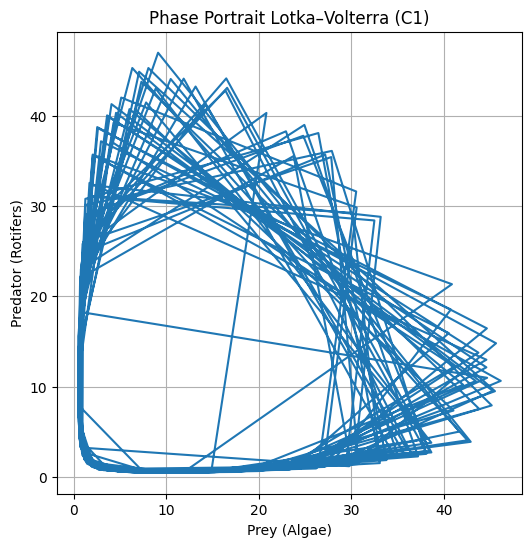

In [34]:
plt.figure(figsize=(6,6))
plt.plot(sim_x, sim_y)
plt.xlabel("Prey (Algae)")
plt.ylabel("Predator (Rotifers)")
plt.title("Phase Portrait Lotka–Volterra (C1)")
plt.grid(True)
plt.show()


In [35]:
print(f"alpha = {alpha:.4f}")
print(f"beta  = {beta:.4f}")
print(f"delta = {delta:.4f}")
print(f"gamma = {gamma:.4f}")


alpha = 1.0000
beta  = 0.1000
delta = 0.1000
gamma = 1.0000


In [36]:
print("alpha, beta, delta, gamma =", alpha, beta, delta, gamma)

# pastikan solver sukses
print("sim.success:", sim.success)
print("sim.message:", sim.message)


alpha, beta, delta, gamma = 1.0000000051958797 0.10000000484039104 0.09999999262060737 1.0000000068359962
sim.success: True
sim.message: The solver successfully reached the end of the integration interval.


In [37]:
print("Min/Max prey(sim):", sim_x.min(), sim_x.max())
print("Min/Max pred(sim):", sim_y.min(), sim_y.max())

print("Min/Max prey(data):", x_data.min(), x_data.max())
print("Min/Max pred(data):", y_data.min(), y_data.max())


Min/Max prey(sim): 0.4451887347516127 46.154267985371966
Min/Max pred(sim): 0.4655923842647148 46.98834347729555
Min/Max prey(data): 0.09 1.91
Min/Max pred(data): 2.61 225.55


In [38]:
res = residuals([alpha, beta, delta, gamma])
rmse_prey = np.sqrt(np.mean((sim_x - x_data)**2))
rmse_pred = np.sqrt(np.mean((sim_y - y_data)**2))

print("RMSE prey:", rmse_prey)
print("RMSE pred:", rmse_pred)
print("Cost (least_squares):", result.cost)


RMSE prey: 16.02944316093862
RMSE pred: 28.853214276400635
Cost (least_squares): 195011.7329612076


In [39]:
i_prey_peak = np.argmax(sim_x)
i_pred_peak = np.argmax(sim_y)

print("t prey peak:", t_data[i_prey_peak])
print("t pred peak:", t_data[i_pred_peak])


t prey peak: 300.97
t pred peak: 370.95


In [40]:
x_star = gamma / delta
y_star = alpha / beta
print("Equilibrium x* (prey):", x_star)
print("Equilibrium y* (pred):", y_star)


Equilibrium x* (prey): 10.000000806299285
Equilibrium y* (pred): 9.999999567919714
